In [12]:
import geopandas as gpd
from geodatasets import get_path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from shapely.geometry import Point

import pandas as pd
import numpy as np

import glob
import os

In [13]:
manhattan_shapes = pd.read_csv('./output/manhattan_shapes.csv')
manhattan_shapes['ZIP Code'] = manhattan_shapes['ZIP Code'].astype(str)

manhattan_shapes

,pop_est,geometry,ZIP Code,SAFMR 1BR
0,23072.0,POLYGON ((-73.98774438827894 40.74406551211233...,10001,3220.0
1,74993.0,POLYGON ((-73.99750380833868 40.71407144673760...,10002,2210.0
2,54682.0,"POLYGON ((-73.98863576728334 40.7229309971691,...",10003,3500.0
3,39363.0,MULTIPOLYGON (((-73.96200720826798 40.80550908...,10026,2270.0
4,3028.0,MULTIPOLYGON (((-74.00826694529984 40.70771979...,10004,3320.0
5,8831.0,"POLYGON ((-74.00782636323468 40.7030866651149,...",10005,3500.0
6,3454.0,POLYGON ((-74.01250844578733 40.70676972563591...,10006,3500.0
7,7023.0,"POLYGON ((-74.0099841276905 40.70980568058192,...",10007,2880.0
8,57925.0,"POLYGON ((-73.98863576728334 40.7229309971691,...",10009,2450.0
9,33730.0,"POLYGON ((-73.9797860547436 40.7349627932416, ...",10010,2840.0


In [14]:
# will look at rent, income, education, and race of all zip codes
racial_2000 = pd.read_csv(os.path.join('racial_data', '2000data.csv'))
racial_2020 = pd.read_csv(os.path.join('racial_data', '2020data.csv'))

racial_2000["White alone"] = racial_2000["White alone"].str.replace(",", "").astype(float)
racial_2000["Black or African American alone"] = racial_2000["Black or African American alone"].str.replace(",", "").astype(float)
racial_2000["Asian alone"] = racial_2000["Asian alone"].str.replace(",", "").astype(float)
racial_2000["Total:"] = racial_2000["Total:"].str.replace(",", "").astype(float)
racial_2000["Population of one race:"] = racial_2000["Population of one race:"].str.replace(",", "").astype(float)

In [15]:
racial_2000["ZIP Code"] = racial_2000["NAME"].str.split(" ").str[-1]
racial_2000["perc_white"] = racial_2000["White alone"] / racial_2000["Population of one race:"]
racial_2000["perc_black"] = racial_2000["Black or African American alone"] / racial_2000["Population of one race:"]
racial_2000["perc_asian"] = racial_2000["Asian alone"] / racial_2000["Population of one race:"]

racial_2020["ZIP Code"] = racial_2020["NAME"].str.split(" ").str[-1]
racial_2020["perc_white"] = racial_2020["P8_003N"] / racial_2020["P8_002N"]
racial_2020["perc_black"] = racial_2020["P8_004N"] / racial_2020["P8_002N"]
racial_2020["perc_asian"] = racial_2020["P8_006N"] / racial_2020["P8_002N"]

In [16]:
percent_change = pd.DataFrame()
percent_change['ZIP Code'] = racial_2000['ZIP Code']
percent_change['ZIP Code'] = percent_change['ZIP Code'].astype(str)

percent_change['perc_white'] = racial_2020['perc_white']
percent_change['perc_asian'] = racial_2020['perc_asian']
percent_change['perc_black'] = racial_2020['perc_black']

percent_change['change_perc_white'] = racial_2020['perc_white'] - racial_2000['perc_white']
percent_change['change_perc_black'] = racial_2020['perc_black'] - racial_2000['perc_black']
percent_change['change_perc_asian'] = racial_2020['perc_asian'] - racial_2000['perc_asian']

percent_change

,ZIP Code,perc_white,perc_asian,perc_black,change_perc_white,change_perc_black,change_perc_asian
0,10001,0.585334,0.215285,0.124101,-0.076544,0.022036,0.055519
1,10002,0.306321,0.448282,0.110456,0.035091,0.031684,-0.063772
2,10003,0.755346,0.156058,0.045146,-0.044735,-0.000330,0.031786
3,10004,0.666405,0.244967,0.054641,-0.108702,-0.008020,0.116212
4,10005,0.721582,0.202327,0.044378,0.027299,0.010539,-0.033379
...,...,...,...,...,...,...,...
61,10271,0.700000,0.000000,0.300000,NaN,NaN,NaN
62,10278,NaN,NaN,NaN,NaN,NaN,NaN
63,10279,0.224138,0.034483,0.603448,NaN,NaN,NaN
64,10280,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
change_racial_groups = ['change_perc_asian', 'change_perc_black', 'change_perc_white']
racial_groups = ['perc_white', 'perc_black', 'perc_asian']

gdf_with_race_change = manhattan_shapes.merge(percent_change[['ZIP Code'] + change_racial_groups + racial_groups], left_on='ZIP Code', right_on='ZIP Code', how='left')
gdf_with_race_change

,pop_est,geometry,ZIP Code,SAFMR 1BR,change_perc_asian,change_perc_black,change_perc_white,perc_white,perc_black,perc_asian
0,23072.0,POLYGON ((-73.98774438827894 40.74406551211233...,10001,3220.0,0.055519,0.022036,-0.076544,0.585334,0.124101,0.215285
1,74993.0,POLYGON ((-73.99750380833868 40.71407144673760...,10002,2210.0,-0.063772,0.031684,0.035091,0.306321,0.110456,0.448282
2,54682.0,"POLYGON ((-73.98863576728334 40.7229309971691,...",10003,3500.0,0.031786,-0.000330,-0.044735,0.755346,0.045146,0.156058
3,39363.0,MULTIPOLYGON (((-73.96200720826798 40.80550908...,10026,2270.0,0.048759,-0.268442,0.192078,0.283034,0.514766,0.068952
4,3028.0,MULTIPOLYGON (((-74.00826694529984 40.70771979...,10004,3320.0,0.116212,-0.008020,-0.108702,0.666405,0.054641,0.244967
5,8831.0,"POLYGON ((-74.00782636323468 40.7030866651149,...",10005,3500.0,-0.033379,0.010539,0.027299,0.721582,0.044378,0.202327
6,3454.0,POLYGON ((-74.01250844578733 40.70676972563591...,10006,3500.0,0.126204,-0.032332,-0.084610,0.714249,0.036141,0.218929
7,7023.0,"POLYGON ((-74.0099841276905 40.70980568058192,...",10007,2880.0,0.061575,-0.061005,0.009469,0.741226,0.068884,0.171032
8,57925.0,"POLYGON ((-73.98863576728334 40.7229309971691,...",10009,2450.0,0.065646,-0.006762,-0.035939,0.593248,0.103014,0.171647
9,33730.0,"POLYGON ((-73.9797860547436 40.7349627932416, ...",10010,2840.0,0.070701,-0.003196,-0.089674,0.712157,0.060497,0.173428


In [18]:
from shapely import wkt

# Convert the 'geometry' column from WKT text to real shapely objects
gdf_with_race_change['geometry'] = gdf_with_race_change['geometry'].apply(wkt.loads)

# Now make it a GeoDataFrame
import geopandas as gpd
gdf_with_race_change = gpd.GeoDataFrame(gdf_with_race_change, geometry='geometry')

# (Optional but good practice) Set the CRS
gdf_with_race_change.set_crs(epsg=4326, inplace=True)  # WGS84 latitude/longitude

,pop_est,geometry,ZIP Code,SAFMR 1BR,change_perc_asian,change_perc_black,change_perc_white,perc_white,perc_black,perc_asian
0,23072.0,"POLYGON ((-73.98774 40.74407, -73.98819 40.743...",10001,3220.0,0.055519,0.022036,-0.076544,0.585334,0.124101,0.215285
1,74993.0,"POLYGON ((-73.9975 40.71407, -73.99709 40.7146...",10002,2210.0,-0.063772,0.031684,0.035091,0.306321,0.110456,0.448282
2,54682.0,"POLYGON ((-73.98864 40.72293, -73.98876 40.722...",10003,3500.0,0.031786,-0.000330,-0.044735,0.755346,0.045146,0.156058
3,39363.0,"MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ...",10026,2270.0,0.048759,-0.268442,0.192078,0.283034,0.514766,0.068952
4,3028.0,"MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ...",10004,3320.0,0.116212,-0.008020,-0.108702,0.666405,0.054641,0.244967
5,8831.0,"POLYGON ((-74.00783 40.70309, -74.00786 40.703...",10005,3500.0,-0.033379,0.010539,0.027299,0.721582,0.044378,0.202327
6,3454.0,"POLYGON ((-74.01251 40.70677, -74.01325 40.705...",10006,3500.0,0.126204,-0.032332,-0.084610,0.714249,0.036141,0.218929
7,7023.0,"POLYGON ((-74.00998 40.70981, -74.01123 40.710...",10007,2880.0,0.061575,-0.061005,0.009469,0.741226,0.068884,0.171032
8,57925.0,"POLYGON ((-73.98864 40.72293, -73.98859 40.723...",10009,2450.0,0.065646,-0.006762,-0.035939,0.593248,0.103014,0.171647
9,33730.0,"POLYGON ((-73.97979 40.73496, -73.97988 40.735...",10010,2840.0,0.070701,-0.003196,-0.089674,0.712157,0.060497,0.173428


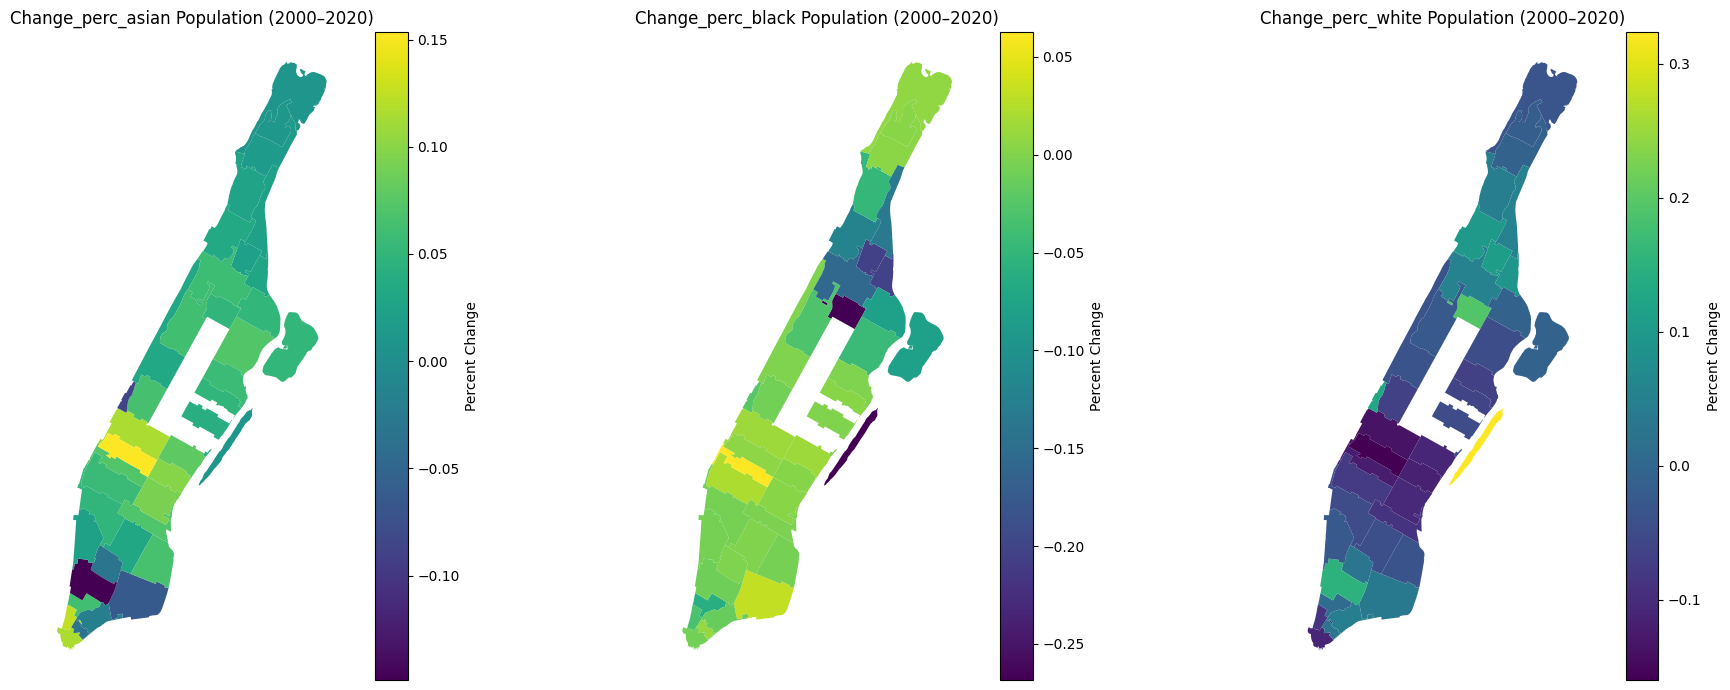

In [19]:
cmap = plt.cm.viridis
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, racial_group in zip(axes, change_racial_groups):
    gdf_with_race_change.plot(
        ax=ax,
        column=racial_group,
        cmap=cmap,
        legend=True,
        legend_kwds={'label': "Percent Change", 'orientation': "vertical"}
    )
    ax.set_title(f"{racial_group.capitalize()} Population (2000–2020)")
    ax.axis('off')  # turn off axes for cleaner map look

plt.tight_layout()
plt.show()

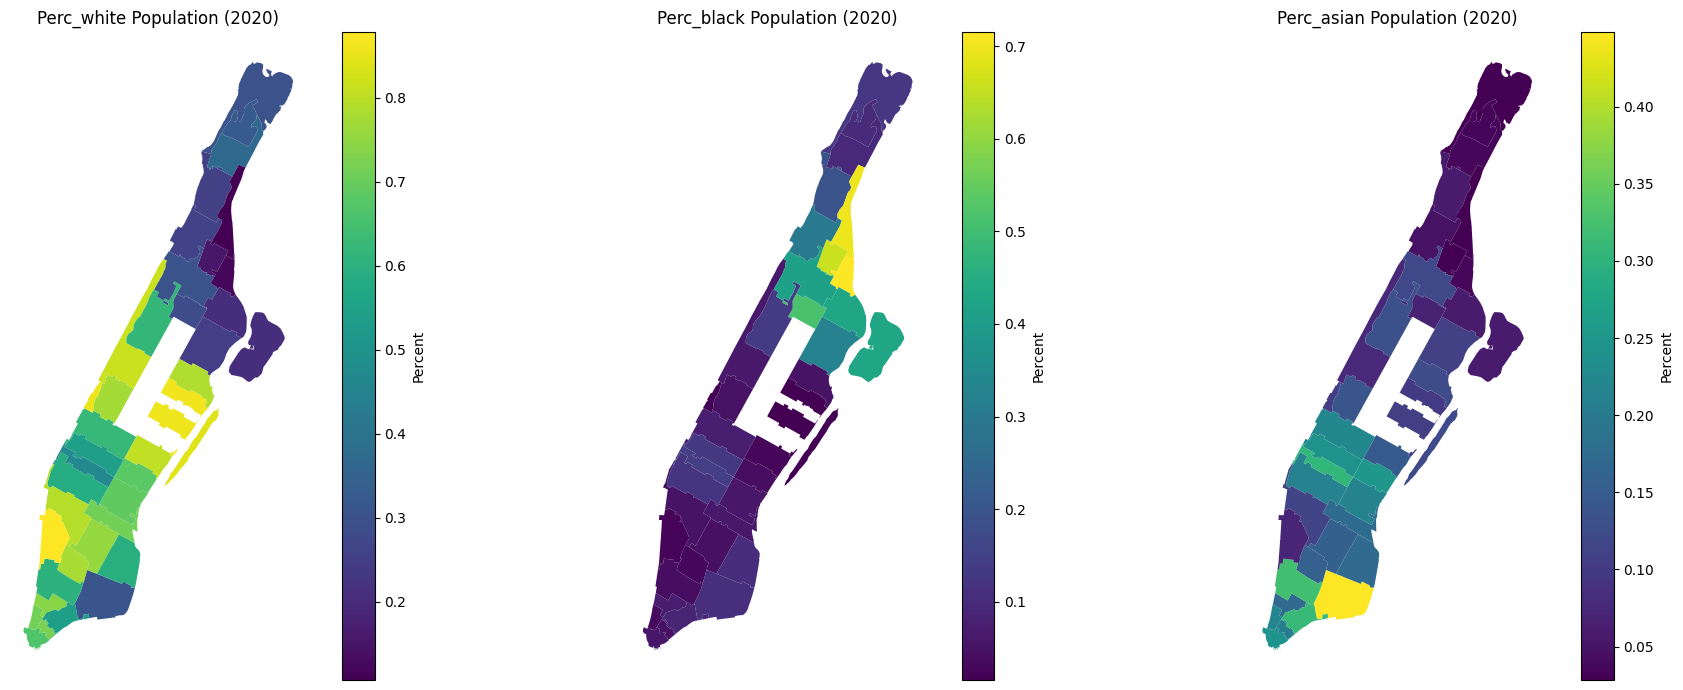

In [20]:
cmap = plt.cm.viridis
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, racial_group in zip(axes, racial_groups):
    gdf_with_race_change.plot(
        ax=ax,
        column=racial_group,
        cmap=cmap,
        legend=True,
        legend_kwds={'label': "Percent", 'orientation': "vertical"}
    )
    ax.set_title(f"{racial_group.capitalize()} Population (2020)")
    ax.axis('off')  # turn off axes for cleaner map look

plt.tight_layout()
plt.show()

In [21]:
gdf_with_race_change.to_csv('./output/racial.csv', index=False)